In [43]:
import pandas as pd
from os import path
import matplotlib.pyplot as plt
from scipy import signal, interpolate
import numpy as np
import folium
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import keras


In [44]:
source_path = r"C:\Users\joses\Mi unidad\TRABAJO\49_profile_estimation\TRABAJO\experimental\bus_913\ordinal_regression"

win_len = 500

speed_stopped_th = 1. # m/s

# Data Extraction

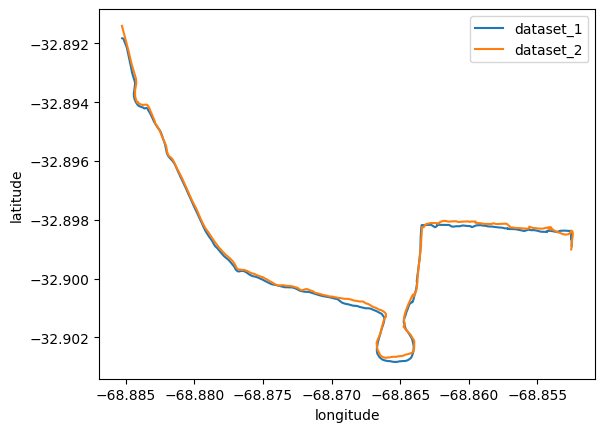

In [45]:
subtract_g = True
fs_acc = 100 # sps


def load_dataset_n(path_n: str, i_ini: int, i_fin: int, n_dataset: int = 0, subtract_g: bool = True, plot: bool = True):
    acc_orig_df_n = pd.read_csv(path.join(source_path, path_n, "AccelerometerUncalibrated.csv")).iloc[i_ini*fs_acc:i_fin*fs_acc, :].reset_index()
    if subtract_g:
        acc_orig_df_n['z'] = acc_orig_df_n['z'] - 9.81
    loc_orig_df_n = pd.read_csv(path.join(source_path, path_n, "Location.csv")).iloc[i_ini:i_fin, :].reset_index()
    loc_orig_df_n = loc_orig_df_n.loc[loc_orig_df_n['speed'] > speed_stopped_th].reset_index()

    if plot and 'loc_orig_df_1' in globals():
        plt.plot(loc_orig_df_1['longitude'], loc_orig_df_1['latitude'], label='dataset_1')
        plt.plot(loc_orig_df_n['longitude'], loc_orig_df_n['latitude'], label=f'dataset_{n_dataset}')
        plt.xlabel('longitude')
        plt.ylabel('latitude')
        plt.legend()
        plt.show()

    return loc_orig_df_n, acc_orig_df_n


# Dataset 1
i_ini, i_fin = 0, 690 # s
loc_orig_df_1, acc_orig_df_1 = load_dataset_n('913_3', i_ini, i_fin, 1, plot=False)

# Dataset 2
i_ini, i_fin = 35, 800 # s
loc_orig_df_2, acc_orig_df_2 = load_dataset_n('913_2', i_ini, i_fin, 2, plot=True)



## Raw Visualization

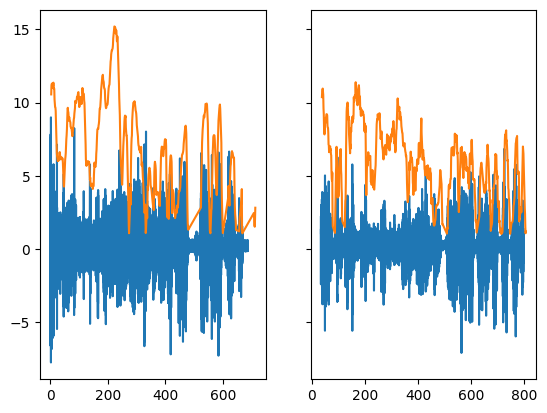

In [46]:
fig, ax = plt.subplots(1, 2, sharey='row')
ax[0].plot(acc_orig_df_1['seconds_elapsed'], acc_orig_df_1['z'])
ax[0].plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'])
ax[1].plot(acc_orig_df_2['seconds_elapsed'], acc_orig_df_2['z'])
ax[1].plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'])

# Feature extraction

In [47]:
# RMS of acceleration
def rolling_rms(acc_orig_df):
    acc2_cum = np.cumsum(acc_orig_df['z']**2)
    acc_rms = np.zeros(acc_orig_df.shape[0])
    for i in range(acc_orig_df.shape[0]-win_len):
        acc_rms[i+win_len] = np.sqrt((acc2_cum[i+win_len] - acc2_cum[i])/win_len)
    acc_feat_df = pd.DataFrame(data=np.vstack((acc_orig_df['seconds_elapsed'].values, acc_rms)).T, 
                                columns=['seconds_elapsed', 'z_rolling_rms']).fillna(0)
    acc_feat_df.reset_index(inplace=True)
    first_non_zero = np.nonzero(acc_feat_df['z_rolling_rms'].values)[0][0]
    acc_feat_df['z_rolling_rms'].values[:first_non_zero] = acc_feat_df['z_rolling_rms'].values[first_non_zero]
    return acc_feat_df

acc_feat_df_1, acc_feat_df_2 = rolling_rms(acc_orig_df_1), rolling_rms(acc_orig_df_2)


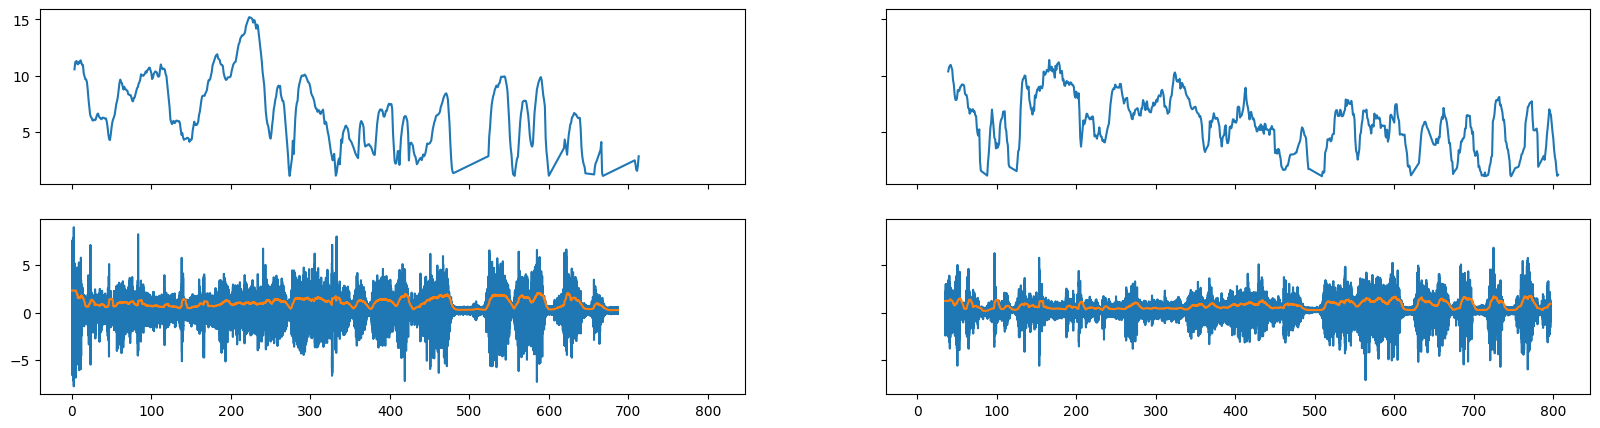

In [48]:
fig, ax = plt.subplots(2, 2, figsize=(20, 5), sharex='all', sharey='row')
ax[0,0].plot(loc_orig_df_1['seconds_elapsed'], loc_orig_df_1['speed'])
ax[1,0].plot(acc_orig_df_1['seconds_elapsed'], acc_orig_df_1['z'])
ax[1,0].plot(acc_feat_df_1['seconds_elapsed'], acc_feat_df_1['z_rolling_rms'])
# ax[1,0].set_xlim([0, 200])
ax[0,1].plot(loc_orig_df_2['seconds_elapsed'], loc_orig_df_2['speed'])
ax[1,1].plot(acc_orig_df_2['seconds_elapsed'], acc_orig_df_2['z'])
ax[1,1].plot(acc_feat_df_2['seconds_elapsed'], acc_feat_df_2['z_rolling_rms'])
# ax[1,1].set_xlim([0, 60])
plt.show()

### Scatter analysis

#### Low frequency

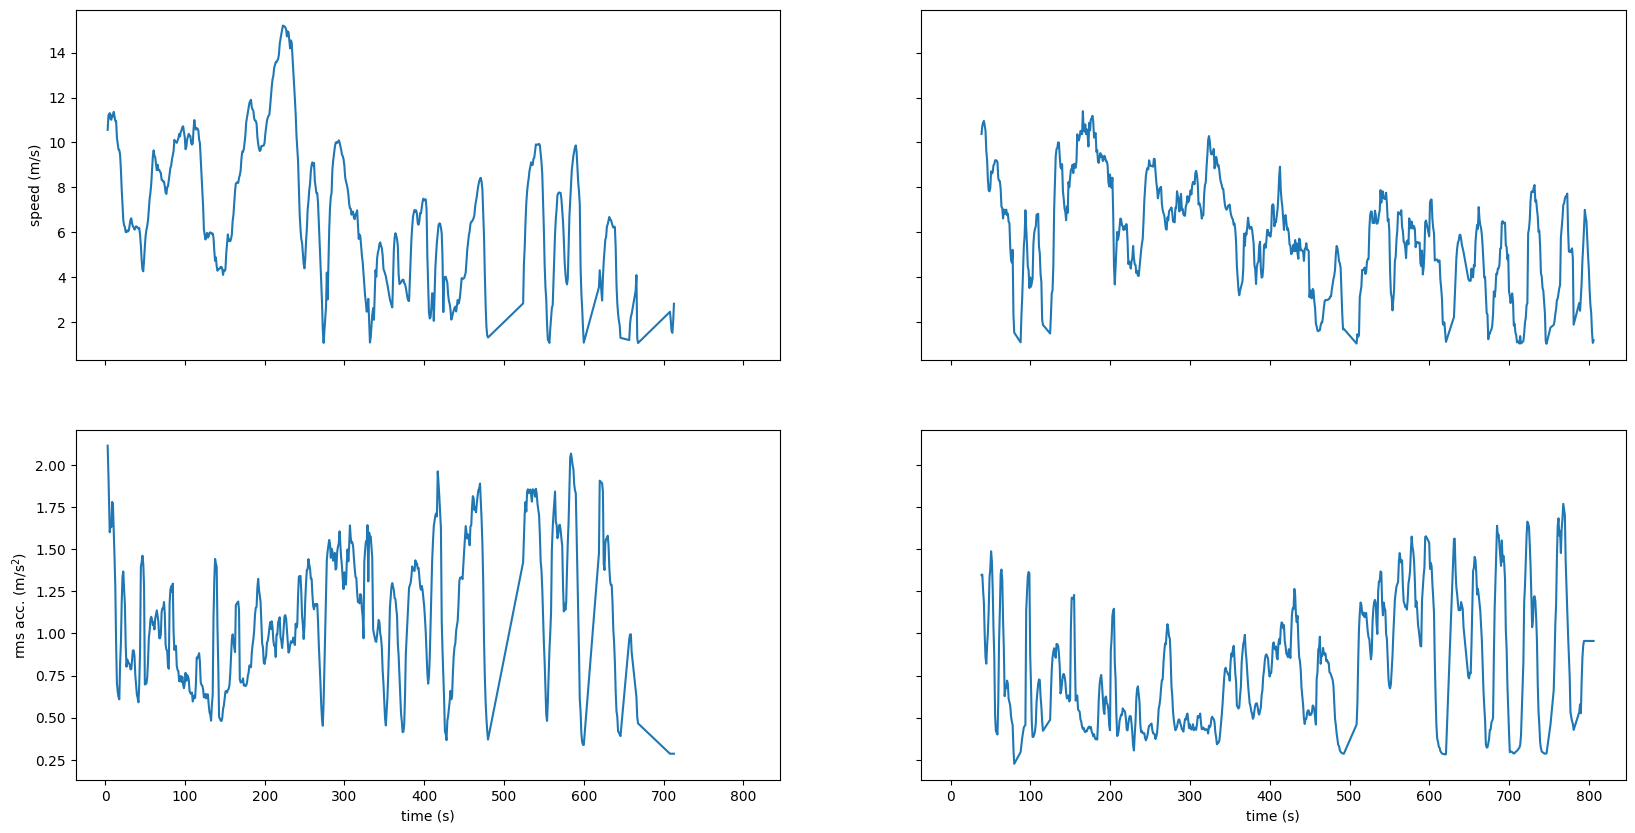

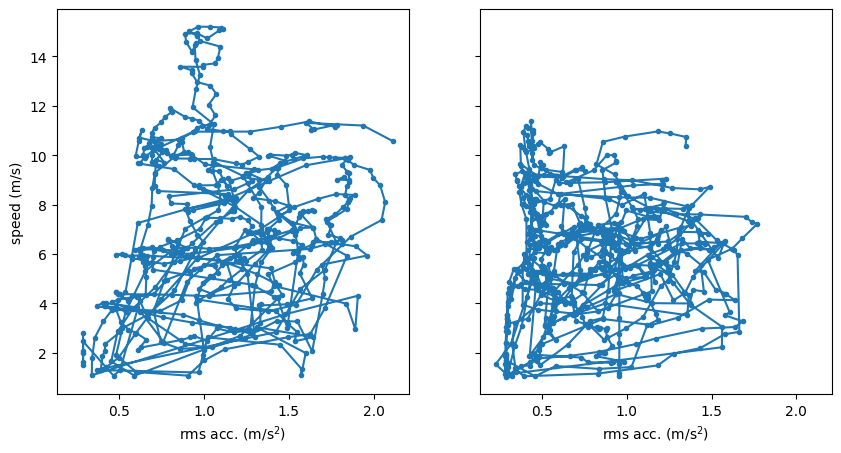

In [49]:
def calc_features_lf_n(loc_orig_df_n, acc_feat_df_n):
    features_lf_n = loc_orig_df_n.loc[:, :]
    features_lf_n['z_rolling_rms'] = \
    np.interp(x=loc_orig_df_n['seconds_elapsed'], 
              xp=acc_feat_df_n['seconds_elapsed'].values-((win_len/fs_acc)/2), fp=acc_feat_df_n['z_rolling_rms'])
    features_lf_n = features_lf_n.drop(columns=['level_0']).reset_index()
    return features_lf_n


features_lf_1, features_lf_2 = calc_features_lf_n(loc_orig_df_1, acc_feat_df_1), calc_features_lf_n(loc_orig_df_2, acc_feat_df_2)


fig, ax = plt.subplots(2, 2, figsize=(20, 10), sharex='all', sharey='row')
ax[0,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['speed'])
ax[0,0].set_ylabel('speed (m/s)')
ax[1,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['z_rolling_rms'])
ax[1,0].set_ylabel('rms acc. (m/s$^2$)')
ax[0,1].plot(features_lf_2['seconds_elapsed'], features_lf_2['speed'])
ax[1,1].plot(features_lf_2['seconds_elapsed'], features_lf_2['z_rolling_rms'])
ax[1,0].set_xlabel('time (s)')
ax[1,1].set_xlabel('time (s)')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
ax[0].plot(features_lf_1['z_rolling_rms'], features_lf_1['speed'], linestyle='-', marker='.')
ax[0].set_xlabel('rms acc. (m/s$^2$)')
ax[0].set_ylabel('speed (m/s)')
ax[1].plot(features_lf_2['z_rolling_rms'], features_lf_2['speed'], linestyle='-', marker='.')
ax[1].set_xlabel('rms acc. (m/s$^2$)')
plt.show()

### Location matching

In [50]:
def times_matches_1_n(loc_orig_df_1, loc_orig_df_n, features_lf_n):
    # Extract coordinates as arrays
    coords_orig = loc_orig_df_1[['latitude', 'longitude']].values
    coords_dest = loc_orig_df_n[['latitude', 'longitude']].values

    # Compute pairwise distances
    distances = cdist(coords_orig, coords_dest, metric='euclidean')

    # Find the nearest point for each origin point
    nearest_indices = distances.argmin(axis=1)
    nearest_distances = distances.min(axis=1)

    # Build a dictionary of time matches
    time_matches_dict = {}
    for i, (dist, idx) in enumerate(zip(nearest_distances, nearest_indices)):
        orig_time = loc_orig_df_1.iloc[i]['seconds_elapsed']
        dest_time = loc_orig_df_n.iloc[idx]['seconds_elapsed']
        time_matches_dict[orig_time] = dest_time

    # location matching
    loc_orig_df_n_matched = loc_orig_df_1.copy()
    for index, row in loc_orig_df_1.iterrows():
        seconds_elapsed_1 = row['seconds_elapsed']
        if index == len(loc_orig_df_n_matched):
            break
        loc_orig_df_n_matched.iloc[index] = loc_orig_df_n.loc[loc_orig_df_n['seconds_elapsed'] == time_matches_dict[seconds_elapsed_1]].values[0]

    # feature matching
    features_lf_n_matched = features_lf_1.copy()
    for index, row in features_lf_1.iterrows():
        seconds_elapsed_1 = row['seconds_elapsed']
        features_lf_n_matched.iloc[index] = features_lf_n.loc[features_lf_n['seconds_elapsed'] == time_matches_dict[seconds_elapsed_1]].values[0]

    return time_matches_dict, loc_orig_df_n_matched, features_lf_n_matched


time_matches_dict, loc_orig_df_2_matched, features_lf_2_matched = times_matches_1_n(loc_orig_df_1, loc_orig_df_2, features_lf_2)


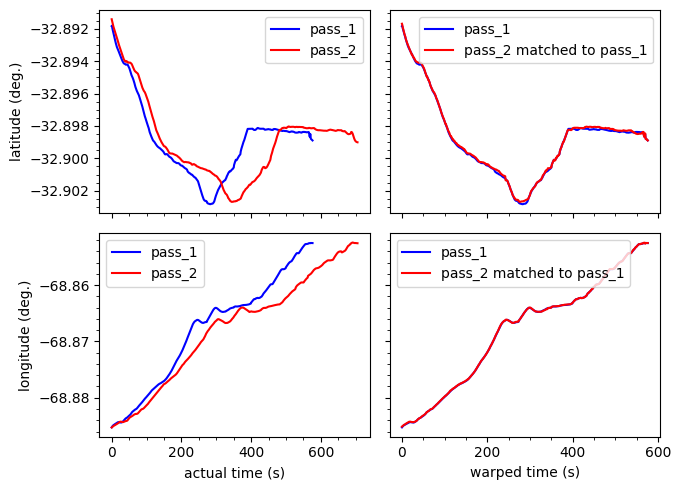

In [51]:

fig, ax = plt.subplots(2, 2, figsize=(7, 5), sharey='row', sharex='col')

ax[0,0].plot(loc_orig_df_1['latitude'].values, color='blue', label='pass_1')
ax[0,0].plot(loc_orig_df_2['latitude'].values, color='red', label='pass_2')
ax[1,0].plot(loc_orig_df_1['longitude'].values, color='blue', label='pass_1')
ax[1,0].plot(loc_orig_df_2['longitude'].values, color='red',  label='pass_2')


ax[0,1].plot(loc_orig_df_1['latitude'].values, color='blue', label='pass_1')
ax[0,1].plot(loc_orig_df_2_matched['latitude'].values, color='red',  label='pass_2 matched to pass_1')
ax[1,1].plot(loc_orig_df_1['longitude'].values, color='blue', label='pass_1')
ax[1,1].plot(loc_orig_df_2_matched['longitude'].values, color='red',  label='pass_2 matched to pass_1')

ax[0,0].set_ylabel('latitude (deg.)')
ax[1,0].set_ylabel('longitude (deg.)')
ax[1,0].set_xlabel('actual time (s)')
ax[1,1].set_xlabel('warped time (s)')

for __ in ax:
    for _ in __:
        _.minorticks_on()
        _.legend()

fig.tight_layout()
plt.show()
fig.savefig('location_based_dtw.pdf')

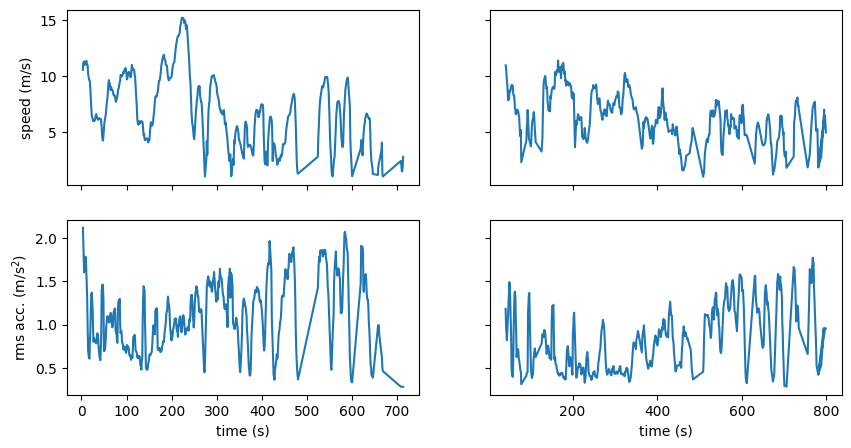

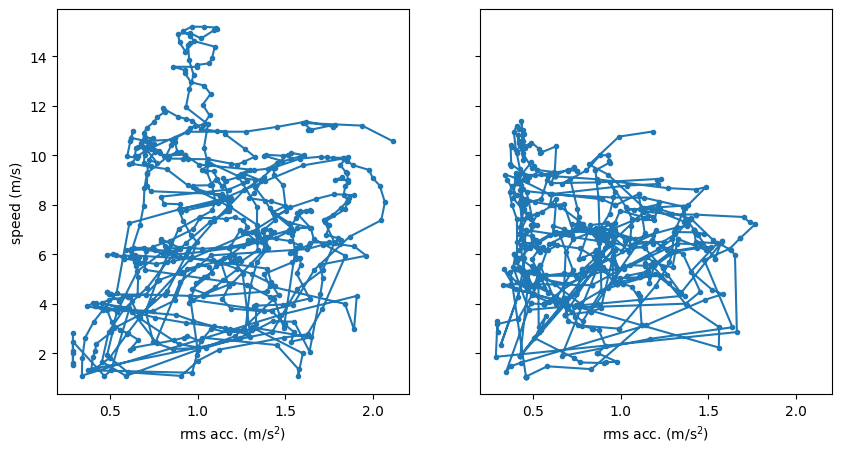

In [52]:
fig, ax = plt.subplots(2, 2, figsize=(10, 5), sharex='col', sharey='row')
ax[0,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['speed'])
ax[0,0].set_ylabel('speed (m/s)')
ax[1,0].plot(features_lf_1['seconds_elapsed'], features_lf_1['z_rolling_rms'])
ax[0,1].plot(features_lf_2_matched['seconds_elapsed'], features_lf_2_matched['speed'])
ax[1,1].plot(features_lf_2_matched['seconds_elapsed'], features_lf_2_matched['z_rolling_rms'])
ax[1,0].set_ylabel('rms acc. (m/s$^2$)')
ax[1,0].set_xlabel('time (s)')
ax[1,1].set_xlabel('time (s)')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex='all', sharey='all')
ax[0].plot(features_lf_1['z_rolling_rms'], features_lf_1['speed'], linestyle='-', marker='.')
ax[0].set_xlabel('rms acc. (m/s$^2$)')
ax[0].set_ylabel('speed (m/s)')
ax[1].plot(features_lf_2_matched['z_rolling_rms'], features_lf_2_matched['speed'], linestyle='-', marker='.')
ax[1].set_xlabel('rms acc. (m/s$^2$)')
plt.show()

# Training

### Datasets

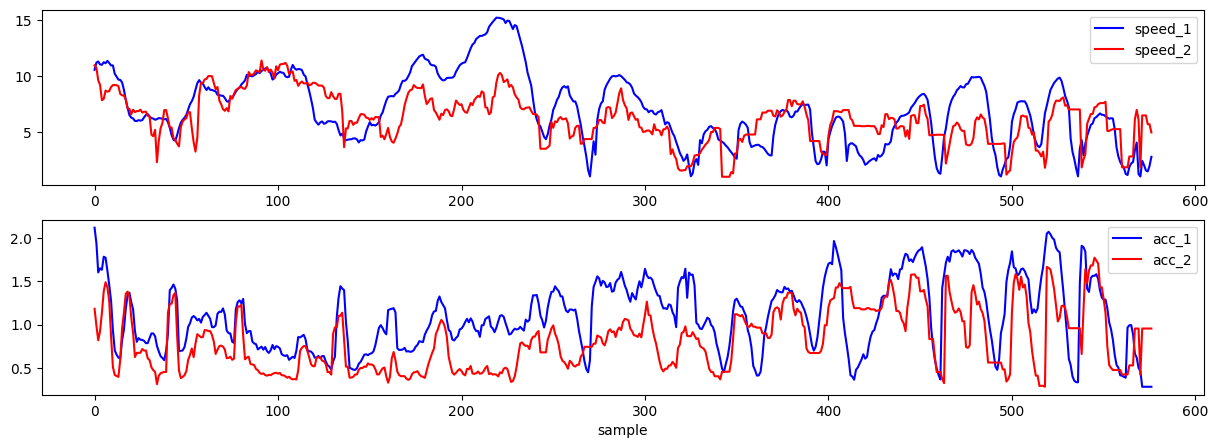

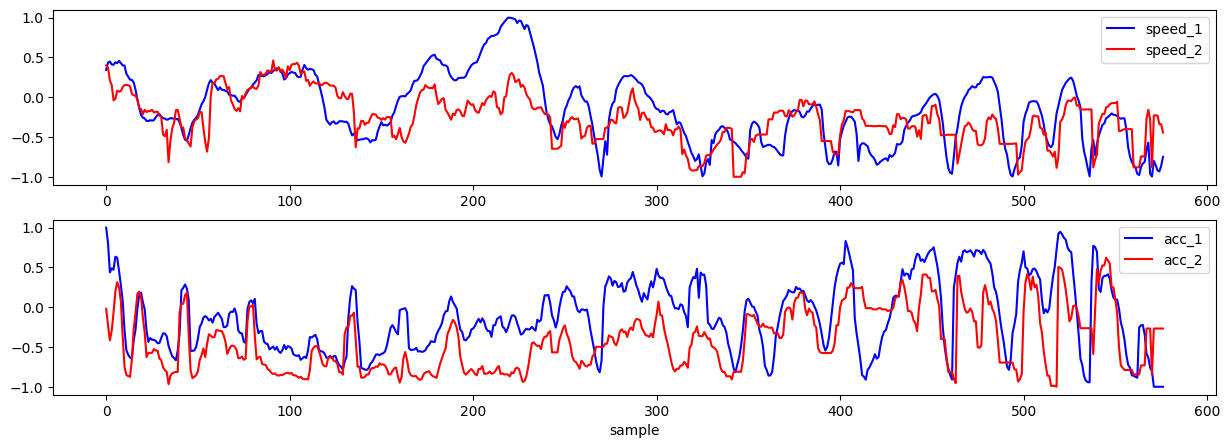

In [53]:
X_equal = np.array([features_lf_1.loc[:, 'speed'].values, features_lf_1.loc[:, 'z_rolling_rms'].values, 
                    features_lf_2_matched.loc[:, 'speed'].values, features_lf_2_matched.loc[:, 'z_rolling_rms'].values]).T
y_equal = np.zeros((X_equal.shape[0], 1))

fig, ax = plt.subplots(2, 1, figsize=(15,5))
ax[0].plot(X_equal[:, 0], color='blue', linestyle='-', label='speed_1')
ax[0].plot(X_equal[:, 2], color='red', linestyle='-', label='speed_2')
ax[0].legend()
ax[1].plot(X_equal[:, 1], color='blue', linestyle='-', label='acc_1')
ax[1].plot(X_equal[:, 3], color='red', linestyle='-', label='acc_2')
ax[1].set_xlabel('sample')
ax[1].legend()

scaler_X = MinMaxScaler((-1,1))
scaler_X.fit(np.vstack((X_equal[:, :2], X_equal[:, 2:])))
X_equal = np.hstack((scaler_X.transform(X_equal[:, :2]), scaler_X.transform(X_equal[:, 2:])))

fig, ax = plt.subplots(2, 1, figsize=(15,5))
ax[0].plot(X_equal[:, 0], color='blue', linestyle='-', label='speed_1')
ax[0].plot(X_equal[:, 2], color='red', linestyle='-', label='speed_2')
ax[0].legend()
ax[1].plot(X_equal[:, 1], color='blue', linestyle='-', label='acc_1')
ax[1].plot(X_equal[:, 3], color='red', linestyle='-', label='acc_2')
ax[1].set_xlabel('sample')
ax[1].legend()

#### Ordinal labels

S_e (577, 4)
S_g and S_l (71, 4)


(array([32.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

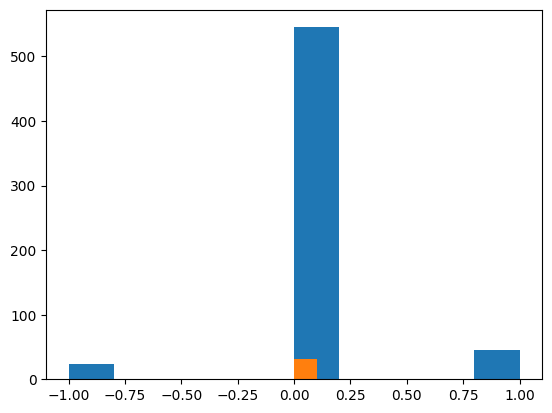

In [54]:
speed_tol = .01 # 
acc_tol = .01 # 

# grid_length = X_equal.shape[0]
# speed_grid = np.random.uniform(min([min(X_equal[:,0]), min(X_equal[:,2])]), max([max(X_equal[:,0]), max(X_equal[:,2])]), (grid_length,1))
# vib_grid = np.random.uniform(min([min(X_equal[:,1]), min(X_equal[:,3])]), max([max(X_equal[:,1]), max(X_equal[:,3])]), (grid_length,1))
# X_grid = np.hstack((speed_grid, vib_grid, speed_grid, vib_grid))

X_grid = X_equal
print('S_e', X_equal.shape)


X_ordinal = []
y_ordinal = []
for x1 in X_grid[:, :2]:
    for x2 in X_grid[:, 2:]:
        if abs(x1[0] - x2[0]) < speed_tol:
            if x1[1] > x2[1] + acc_tol:
                X_ordinal.append(np.hstack((x1, x2)))
                y_ordinal.append(1.)
            elif x1[1] < x2[1] - acc_tol:
                X_ordinal.append(np.hstack((x1, x2)))
                y_ordinal.append(-1.)
X_ordinal = np.array(X_ordinal)
y_ordinal = np.array(y_ordinal).reshape((-1, 1))

X_ordinal, _, y_ordinal, _ = train_test_split(X_ordinal, y_ordinal, test_size=0.985, shuffle=True)
print('S_g and S_l', X_ordinal.shape)


X = np.vstack((X_equal, X_ordinal))
y = np.vstack((y_equal, y_ordinal))
shuffler = np.arange(X.shape[0])
np.random.default_rng().shuffle(shuffler)
X = X[shuffler, :]
y = y[shuffler, :]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=True)

plt.hist(y_train)
plt.hist(y_test)

## Model definition

In [55]:
x1_nn_input = keras.layers.Input(shape=(2,))
x2_nn_input = keras.layers.Input(shape=(2,))

activation = 'tanh'
reg = None
dropout = 0.
shared_layers = [
    # keras.layers.Dense(100, activation=activation, kernel_regularizer=reg, bias_regularizer=reg, activity_regularizer=reg),
    # keras.layers.Dense(100, activation=activation, kernel_regularizer=reg, bias_regularizer=reg, activity_regularizer=reg),
    # keras.layers.Dense(100, activation=activation, kernel_regularizer=reg, bias_regularizer=reg, activity_regularizer=reg),
    keras.layers.Dense(1, activation='linear', kernel_regularizer=reg, bias_regularizer=reg, activity_regularizer=reg)
    ]
first = True
for layer in shared_layers:
    if first:
        x1_nn = layer(x1_nn_input)
        x2_nn = layer(x2_nn_input)
        first = False    
    else:
        x1_nn = layer(x1_nn)
        x2_nn = layer(x2_nn)

y_nn = keras.layers.Lambda(lambda x12: keras.backend.tanh(x12[0] - x12[1]), name='ranker')((x1_nn, x2_nn))

model = keras.models.Model(inputs=[x1_nn_input, x2_nn_input], outputs=[y_nn])
model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 2)]                  0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 2)]                  0         []                            
                                                                                                  
 dense_1 (Dense)             (None, 1)                    3         ['input_3[0][0]',             
                                                                     'input_4[0][0]']             
                                                                                                  
 ranker (Lambda)             (None, 1)                    0         ['dense_1[0][0]',       

In [56]:
keras.utils.plot_model(model, to_file='model_simpler_model.pdf',
                        show_shapes=True,
                        show_dtype=False,
                        show_layer_names=True,
                        expand_nested=True,
                        dpi=96,
                        layer_range=None,
                        show_layer_activations=True,
                        show_trainable=True)

In [57]:
model_x1 = keras.models.Model(inputs=[x1_nn_input], outputs=[x1_nn])
model_x1.build(input_shape=x1_nn_input.shape)
# model_x1.summary()

## Model training

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 0.1049 - val_loss: 0.0254 - lr: 0.1000
Epoch 2/100
1/1 [==============================] - 0s 84ms/step - loss: 0.1046 - val_loss: 0.0253 - lr: 0.1000
Epoch 3/100
1/1 [==============================] - 0s 79ms/step - loss: 0.1042 - val_loss: 0.0251 - lr: 0.1000
Epoch 4/100
1/1 [==============================] - 0s 97ms/step - loss: 0.1039 - val_loss: 0.0250 - lr: 0.1000
Epoch 5/100
1/1 [==============================] - 0s 191ms/step - loss: 0.1036 - val_loss: 0.0249 - lr: 0.1000
Epoch 6/100
1/1 [==============================] - 0s 122ms/step - loss: 0.1033 - val_loss: 0.0248 - lr: 0.1000
Epoch 7/100
1/1 [==============================] - 0s 93ms/step - loss: 0.1030 - val_loss: 0.0247 - lr: 0.1000
Epoch 8/100
1/1 [==============================] - 0s 98ms/step - loss: 0.1028 - val_loss: 0.0246 - lr: 0.1000
Epoch 9/100
1/1 [==============================] - 0s 116ms/step - loss: 0.1026 - val_loss: 0.0245 - lr: 0.1000


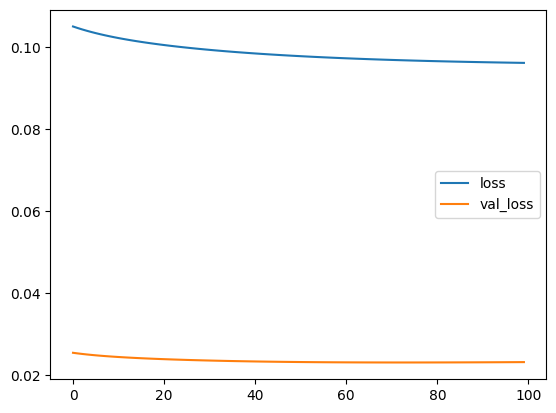

In [58]:
learning_rate = .1
batch_size = X_train.shape[0]
epochs = 100
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.9,
                                              patience=50, verbose=1,min_lr=1e-6)
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=200)

model.compile(optimizer=keras.optimizers.SGD(learning_rate=learning_rate), loss='mse')
history = model.fit(x=[X_train[:, :2], X_train[:, 2:]], y=[y_train], batch_size=batch_size, epochs=epochs, 
                    validation_data=[[X_test[:, :2], X_test[:, 2:]], [y_test]],
                    callbacks=[reduce_lr, early_stopping])
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [59]:
import os


directory = r'C:\Users\joses\Mi unidad\TRABAJO\49_profile_estimation\TRABAJO\experimental\bus_913\ordinal_regression'
model.save(os.path.join(directory, 'model_913_simpler.keras'))
model_x1.save(os.path.join(directory, 'model_x1_913_simpler.keras'))

model.load_weights(os.path.join(directory, 'model_913_simpler.keras'))
model_x1.load_weights(os.path.join(directory, 'model_x1_913_simpler.keras'))

## Test

In [60]:
import plotly.graph_objects as go


layout = go.Layout(width=800, height=600)
x1_nn_train_pred = model_x1.predict([X_train[:, :2]])
fig3 = go.Figure(data=go.Scatter3d(x=X_train[:, 0], y=X_train[:, 1], z=x1_nn_train_pred[:,0],
                                   mode='markers', marker=dict(size=5), name='train'), layout=layout)

x1_nn_test_pred = model_x1.predict([X_test[:, :2]])
fig3.add_trace(go.Scatter3d(x=X_test[:, 0], y=X_test[:, 1], z=x1_nn_test_pred[:,0],
                            mode='markers', marker=dict(size=5), name='test'))
fig3.show()

layout = go.Layout(width=800, height=600)
X1_mesh, X2_mesh = np.meshgrid(np.linspace(-1., 1., 20), np.linspace(-1, 1, 20))
x1_mesh, x2_mesh = np.ravel(X1_mesh).reshape((-1, 1)), np.ravel(X2_mesh).reshape((-1, 1))
X1_mesh = np.hstack((x1_mesh, x2_mesh))
y_mesh = model_x1.predict([X1_mesh])
fig4 = go.Figure(data=go.Scatter3d(x=x1_mesh.ravel(), y=x2_mesh.ravel(), z=y_mesh.ravel(),
                                   mode='markers', marker=dict(size=5)), layout=layout)
fig4.show()

layout = go.Layout(width=800, height=600)
X1_mesh, X2_mesh = np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))
x1_mesh, x2_mesh = np.ravel(X1_mesh).reshape((-1, 1)), np.ravel(X2_mesh).reshape((-1, 1))
X1_mesh = np.hstack((x1_mesh, x2_mesh))
y_mesh = model_x1.predict([X1_mesh])
X1_mesh_actual = scaler_X.inverse_transform(X1_mesh)
fig4 = go.Figure(data=go.Scatter3d(x=X1_mesh_actual[:, 0], 
                                   y=X1_mesh_actual[:, 1], z=y_mesh.ravel(),
                                   mode='markers', marker=dict(size=5)), layout=layout)
fig4.show()

2/2 [==============================] - 0s 14ms/step


13/13 [==============================] - 0s 10ms/step


13/13 [==============================] - 1s 14ms/step


1/1 [==============================] - 0s 225ms/step


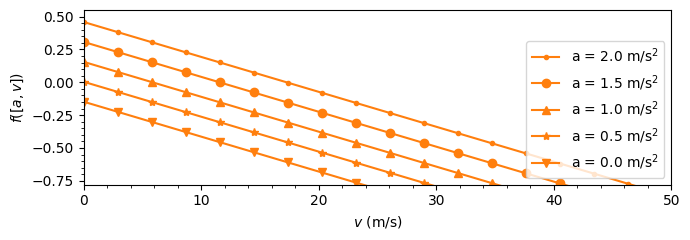

In [61]:
accs_plot = np.linspace(0, 2, 5)[::-1]
speeds_plot = np.linspace(0, 55, 20)
fig, ax = plt.subplots(1, 1, figsize=(7,2.5), sharex='col')
markers = ['.', 'o', '^', '*', 'v']
for acc, marker in zip(accs_plot, markers):
    X_test_speed = np.hstack((speeds_plot.reshape((-1, 1)), np.zeros((speeds_plot.shape[0], 1)) + acc))
    ax.plot(speeds_plot, model_x1.predict(scaler_X.transform(X_test_speed)), label=f'a = {acc} '+ r'm/s$^{2}$',
            color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], marker=marker)
ax.set_xlabel(r'$v$ (m/s)')
ax.set_ylabel(r'$f([a, v])$')
ax.set_xlim((0,50))
ax.set_ylim((-.78, .55))
ax.minorticks_on()
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()
fig.savefig('plot_f_real_world_simpler_model.pdf')

## Robustness testing

In [62]:
indices = [43, 100, 190, 220, 460, 540]


19/19 [==============================] - 0s 8ms/step


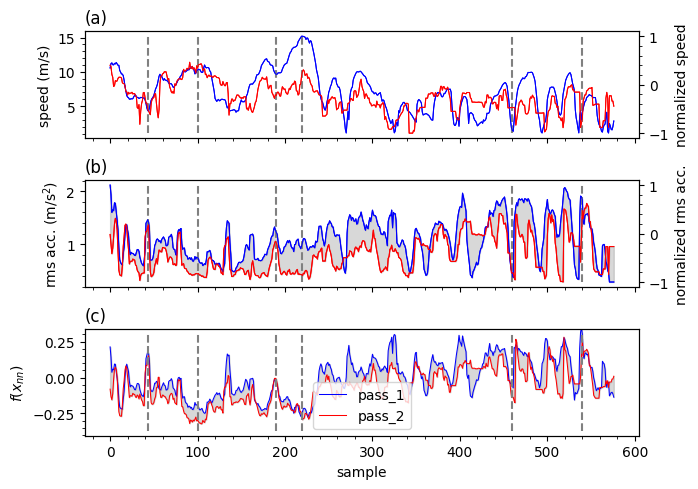

In [63]:
X_equal_actual = np.array([features_lf_1.loc[:, 'speed'].values, features_lf_1.loc[:, 'z_rolling_rms'].values, 
              features_lf_2_matched.loc[:, 'speed'].values, features_lf_2_matched.loc[:, 'z_rolling_rms'].values]).T
y_equal = np.zeros((X_equal.shape[0], 1))

X_equal = np.hstack((scaler_X.transform(X_equal_actual[:, :2]), scaler_X.transform(X_equal_actual[:, 2:])))

x1_1_pred = model_x1.predict([X_equal[:, :2]])
x1_2_pred = model_x1.predict([X_equal[:, 2:]])

fig, ax = plt.subplots(3, 1, figsize=(7,5), sharex='col')

ax_twin = []
for i, _ in enumerate(ax):
    _.minorticks_on()
    ax_twin.append(_.twinx())
    ax_twin[-1].minorticks_on()
ax_twin[2].set_yticks([])

for _ in ax_twin:
    for idx in indices:
        _.plot([idx, idx], [-1, 1], linestyle='--', color='gray')

ax_twin[0].plot(X_equal[:, 0], color='blue', linestyle='-', linewidth=0.75)
ax_twin[0].plot(X_equal[:, 2], color='red', linestyle='-', linewidth=0.75)
ax[0].plot(X_equal_actual[:, 0], color='blue', label='pass_1', linewidth=0.75)
ax[0].plot(X_equal_actual[:, 2], color='red', label='pass_2', linewidth=0.75)
ax[0].set_ylabel('speed (m/s)')
ax_twin[0].set_ylabel('normalized speed')
# ax[0].legend()
ax_twin[1].plot(X_equal[:, 1], color='blue', linestyle='-', linewidth=0.75)
ax_twin[1].plot(X_equal[:, 3], color='red', linestyle='-', linewidth=0.75)
ax[1].plot(X_equal_actual[:, 1], color='blue', linestyle='-', label='pass_1', linewidth=0.75)
ax[1].plot(X_equal_actual[:, 3], color='red', linestyle='-', label='pass_2', linewidth=0.75)
ax[1].fill_between(np.linspace(0,x1_1_pred.shape[0]-1,x1_1_pred.shape[0]), 
                   (X_equal_actual[:, 1]).ravel(), 
                   (X_equal_actual[:, 3]).ravel(), 
                   color='grey', alpha=0.3)  # Adjust alpha for transparency if needed
ax[1].set_ylabel(r'rms acc. (m/s$^2$)')
ax_twin[1].set_ylabel('normalized rms acc.')
# ax[1].legend()
ax[2].plot(x1_1_pred, color='blue', linestyle='-', label='pass_1', linewidth=0.75)
ax[2].plot(x1_2_pred, color='red', linestyle='-', label='pass_2', linewidth=0.75)
ax[2].fill_between(np.linspace(0,x1_1_pred.shape[0]-1,x1_1_pred.shape[0]), 
                   (x1_1_pred).ravel(), 
                   (x1_2_pred).ravel(), 
                   color='grey', alpha=0.3)  # Adjust alpha for transparency if needed
ax[2].set_ylabel(r'$f(x_{nn})$')
ax[2].legend(loc='lower center', )
ax[2].set_xlabel('sample')
ax[2].set_ylim([np.mean((x1_1_pred+x1_2_pred)/2)-3*np.std((x1_1_pred+x1_2_pred)/2), 
                np.mean((x1_1_pred+x1_2_pred)/2)+3*np.std((x1_1_pred+x1_2_pred)/2)])
_ = [ax[i].set_title('(' + chr(ord('a')+i) + ')', loc='left') for i in range(3)]
plt.tight_layout()
plt.savefig('reg_results'+'.pdf')
plt.show()

#### Maps

In [64]:
# Create a color map
from matplotlib import cm
from matplotlib.colors import Normalize


norm = Normalize(vmin=0, vmax=1)

def value_to_reds(value):
    cmap = plt.colormaps['Reds']
    rgba = cmap(norm(value))
    return f'#{int(rgba[0]*255):02x}{int(rgba[1]*255):02x}{int(rgba[2]*255):02x}'

def value_to_blues(value):
    cmap = plt.colormaps['Blues']
    rgba = cmap(norm(value))
    return f'#{int(rgba[0]*255):02x}{int(rgba[1]*255):02x}{int(rgba[2]*255):02x}'

In [65]:
circ_rad = 10

# Create a map centered at the mean latitude and longitude of loc_orig_df_2
center_lat = loc_orig_df_1['latitude'].mean()
center_lon = loc_orig_df_1['longitude'].mean()
mymap = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')

f1, f2 = x1_1_pred[:,0], x1_2_pred[:,0]
f1, f2 = f1-np.min(f1), f2-np.min(f2)
f1, f2 = f1/np.max(f1), f2/np.max(f2)

# Plot the latitude and longitude data on the map
for index in range(loc_orig_df_1.shape[0]):
    row1, row2 = loc_orig_df_1.iloc[index,:], loc_orig_df_2_matched.iloc[index,:]
    folium.Circle([row1['latitude'], row1['longitude']],
                        radius=circ_rad*f1[index],
                        color=value_to_blues(f1[index]),
                        fill=False).add_to(mymap)
    folium.Circle([row2['latitude'], row2['longitude']],
                        radius=circ_rad*f2[index],
                        color=value_to_reds(f1[index]),
                        fill=False).add_to(mymap)
    
    # Add sample numbers every 10th point
    if index % 100 == 0:
        folium.Marker(
            [row1['latitude'], row1['longitude']],
            icon=folium.DivIcon(html=f"""<div style="font-size: 12pt; color : gray"><b>{index}</b></div>""")
        ).add_to(mymap)
    # and at:
    if index in indices:
        folium.Marker(
            [row1['latitude'], row1['longitude']],
            icon=folium.DivIcon(html=f"""<div style="font-size: 16pt; color : black"><b>{index}</b></div>""")
        ).add_to(mymap)
        print(f'sample {index}' + f"{(row1['latitude'], row1['longitude'])}, f1 = {x1_1_pred[index,0]}, f2 = {x1_2_pred[index,0]}, "
                                  f"f = {np.round(0.5*(x1_1_pred[index,0]+x1_2_pred[index,0]), 2)} "
                                  f"± {np.round((0.5*np.abs(x1_1_pred[index,0]-x1_2_pred[index,0])), 2)}; "
                                  f"{scaler_X.inverse_transform(X_equal[index, :2].reshape(1, -1)), scaler_X.inverse_transform(X_equal[index, 2:].reshape(1, -1))}")


# Save the map to an HTML file
mymap.save("map_f.html")



sample 43(-32.8942041, -68.8835737), f1 = 0.17976585030555725, f2 = 0.13923533260822296, f = 0.16 ± 0.02; (array([[4.34138107, 1.46200705]]), array([[4.47266388, 1.33991347]]))
sample 100(-32.8977337, -68.8798387), f1 = -0.1951751410961151, f2 = -0.29583078622817993, f = -0.25 ± 0.05; (array([[10.26542187,  0.74503203]]), array([[10.53293133,  0.43669244]]))
sample 190(-32.9002953, -68.8730501), f1 = -0.03272620961070061, f2 = -0.010444767773151398, f = -0.02 ± 0.01; (array([[9.61803818, 1.223776  ]]), array([[6.53470945, 1.02716121]]))
sample 220(-32.9008631, -68.868933), f1 = -0.23742976784706116, f2 = -0.29394233226776123, f = -0.27 ± 0.03; (array([[15.18928242,  1.03701826]]), array([[10.10798073,  0.40569727]]))
sample 460(-32.8982391, -68.8598167), f1 = -0.05803404748439789, f2 = -0.13731294870376587, f = -0.1 ± 0.04; (array([[1.41982591, 0.42231078]]), array([[4.78907776, 0.45609985]]))
sample 540(-32.8983821, -68.8539608), f1 = 0.3038770258426666, f2 = 0.2678833305835724, f = 0

In [66]:
circ_rad = 5

# Create a map centered at the mean latitude and longitude of loc_orig_df_2
center_lat = loc_orig_df_1['latitude'].mean()
center_lon = loc_orig_df_1['longitude'].mean()
mymap = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles='OpenStreetMap')

acc1, acc2 = X_equal[:, 1], X_equal[:, 3]
acc1, acc2 = acc1-np.min(acc1), acc2-np.min(acc2)
acc1, acc2 = acc1/np.max(acc1), acc2/np.max(acc2)

# Plot the latitude and longitude data on the map
for index in range(loc_orig_df_1.shape[0]):
    row1, row2 = loc_orig_df_1.iloc[index,:], loc_orig_df_2_matched.iloc[index,:]
    folium.Circle([row1['latitude'], row1['longitude']],
                        radius=circ_rad*acc1[index],
                        color=value_to_blues(acc1[index]),
                        fill=False).add_to(mymap)
    folium.Circle([row2['latitude'], row2['longitude']],
                        radius=circ_rad*acc2[index],
                        color=value_to_reds(acc2[index]),
                        fill=False).add_to(mymap)

# Save the map to an HTML file
mymap.save("map_acc.html")

### Correlations

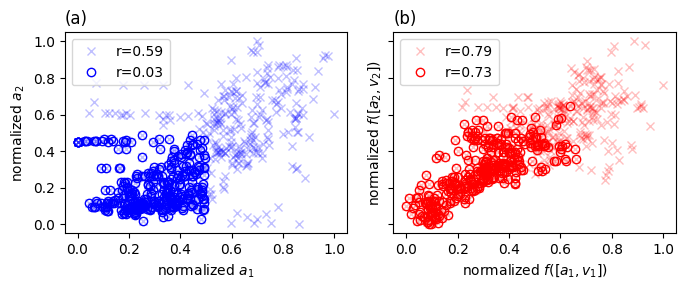

In [67]:
# acceleration correlation
fig, ax = plt.subplots(1, 2, figsize=(7, 3), sharex='all', sharey=all)
ax[0].plot(acc1, acc2, linestyle='', color='blue', marker='x', alpha=0.25, label=f'r={np.round(np.corrcoef(acc1, acc2)[1,0], 2)}')
ax[0].set_xlabel('acc_1')
ax[0].set_ylabel('acc_2')
ax[0].legend()
ax[1].plot(f1, f2, linestyle='', color='red', marker='x', alpha=0.25, label=f'r={np.round(np.corrcoef(f1, f2)[1,0], 2)}')
ax[1].set_xlabel('f_1')
ax[1].set_ylabel('f_2')
ax[1].legend()
# plt.show()


# acceleration correlation
acc_low_ = np.vstack((acc1, acc2)).T
acc_low = acc_low_[(acc_low_[:, 0] < 0.5) & (acc_low_[:, 1] < 0.5), :]
acc1_low, acc2_low = acc_low[:, 0], acc_low[:, 1]
f_low = np.vstack((f1, f2)).T
f_low = f_low[(acc_low_[:, 0] < 0.5) & (acc_low_[:, 1] < 0.5), :]
f1_low, f2_low = f_low[:, 0], f_low[:, 1]

ax[0].plot(acc1_low, acc2_low, linestyle='', color='blue', marker='o', markerfacecolor='none', label=f'r={np.round(np.corrcoef(acc1_low, acc2_low)[1,0], 2)}')
ax[0].set_xlabel('normalized $a_1$')
ax[0].set_ylabel('normalized $a_2$')
ax[0].legend()
ax[0].set_title('(a)', loc='left')
ax[1].plot(f1_low, f2_low, linestyle='', color='red', marker='o', markerfacecolor='none', label=f'r={np.round(np.corrcoef(f1_low, f2_low)[1,0], 2)}')
ax[1].set_xlabel('normalized $f([a_1, v_1])$')
ax[1].set_ylabel('normalized $f([a_2, v_2])$')
ax[1].legend()
ax[1].set_title('(b)', loc='left')

plt.tight_layout()
fig.savefig('corr_simpler_model.pdf')

# Test with other records

## Prediction on the third pass

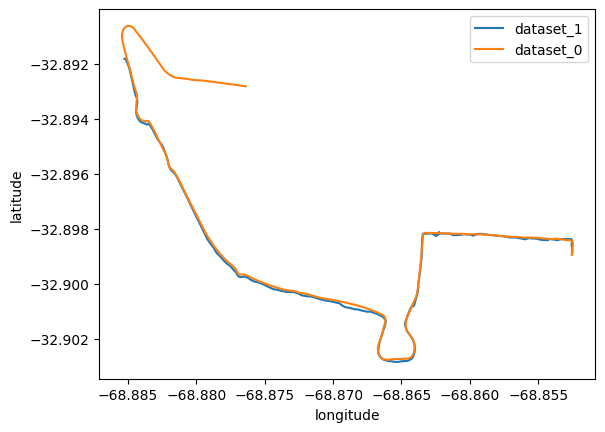

19/19 [==============================] - 0s 4ms/step


Text(0.5, 0, 'sample')

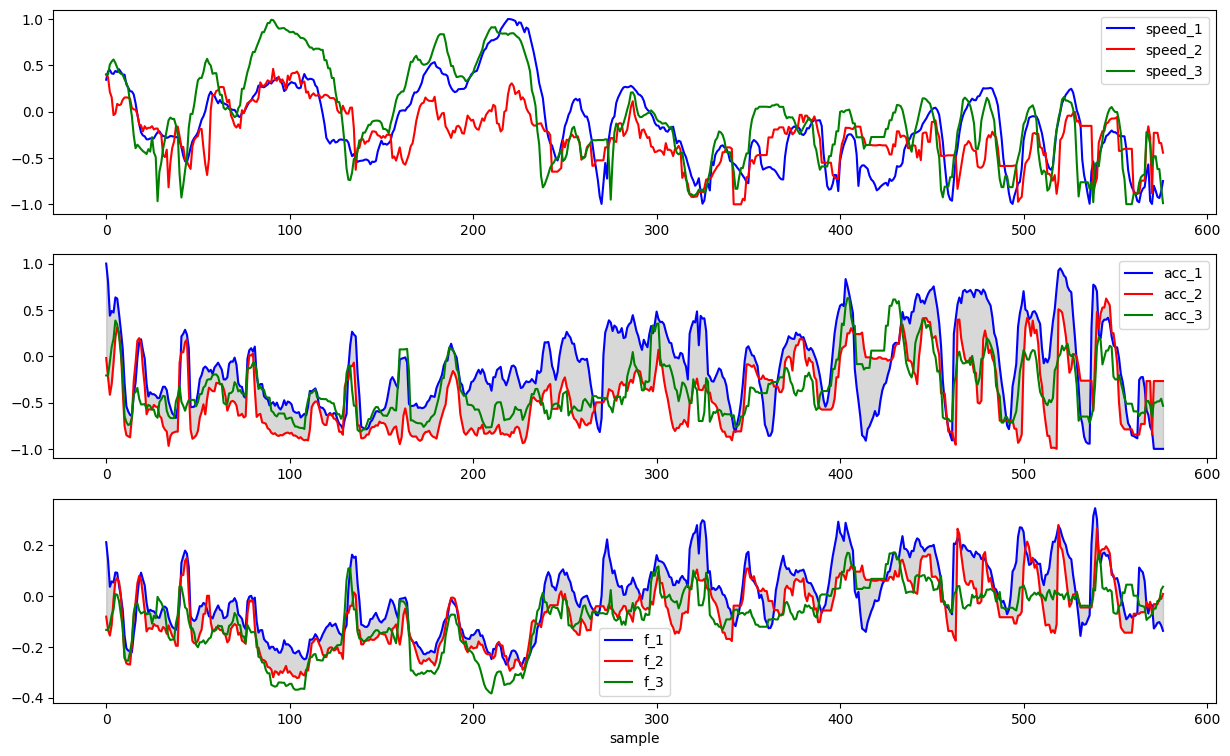

In [68]:
# Dataset 3
i_ini, i_fin = 10, 800 # s
loc_orig_df_3, acc_orig_df_3 = load_dataset_n('913_1', i_ini, i_fin)
acc_feat_df_3 = rolling_rms(acc_orig_df_3)
features_lf_3 = calc_features_lf_n(loc_orig_df_3, acc_feat_df_3)
_, loc_orig_df_3_matched, features_lf_3_matched = times_matches_1_n(loc_orig_df_1, loc_orig_df_3, features_lf_3)

X_1 = X_equal[:, :2]
X_2 = X_equal[:, 2:]
X_3 = scaler_X.transform(np.array([features_lf_3_matched.loc[:, 'speed'].values, 
                                   features_lf_3_matched.loc[:, 'z_rolling_rms'].values]).T)
x1_3_pred = model_x1.predict([X_3])

fig, ax = plt.subplots(3, 1, figsize=(15,9))
ax[0].plot(X_1[:, 0], color='blue', linestyle='-', label='speed_1')
ax[0].plot(X_2[:, 0], color='red', linestyle='-', label='speed_2')
ax[0].plot(X_3[:, 0], color='green', linestyle='-', label='speed_3')
ax[0].legend()

ax[1].plot(X_1[:, 1], color='blue', linestyle='-', label='acc_1')
ax[1].plot(X_2[:, 1], color='red', linestyle='-', label='acc_2')
ax[1].plot(X_3[:, 1], color='green', linestyle='-', label='acc_3')
ax[1].fill_between(np.linspace(0,x1_1_pred.shape[0]-1,x1_1_pred.shape[0]), 
                   (X_equal[:, 1]).ravel(), 
                   (X_equal[:, 3]).ravel(), 
                   color='grey', alpha=0.3)  # Adjust alpha for transparency if needed
ax[1].legend()

ax[2].plot(x1_1_pred, color='blue', linestyle='-', label='f_1')
ax[2].plot(x1_2_pred, color='red', linestyle='-', label='f_2')
ax[2].plot(x1_3_pred, color='green', linestyle='-', label='f_3')
ax[2].fill_between(np.linspace(0,x1_1_pred.shape[0]-1,x1_1_pred.shape[0]), 
                   (x1_1_pred).ravel(), 
                   (x1_2_pred).ravel(), 
                   color='grey', alpha=0.3)  # Adjust alpha for transparency if needed
ax[2].legend()
ax[2].set_xlabel('sample')


## Select samples of similar speed

In [69]:
speeds_of_interest = [5., 7.5, 10., 12.5]
speeds_of_interest_tol = 0.2


X_3_actual = scaler_X.inverse_transform(X_3)

selected_samples = {speed: X_3_actual.copy() for speed in speeds_of_interest}

for speed in speeds_of_interest:
    for i in range(X_3_actual.shape[0]):
        if not (np.abs(X_3_actual[i, 0] - speed) < speeds_of_interest_tol):
            selected_samples[speed][i, :] = np.nan* selected_samples[speed][i, :]

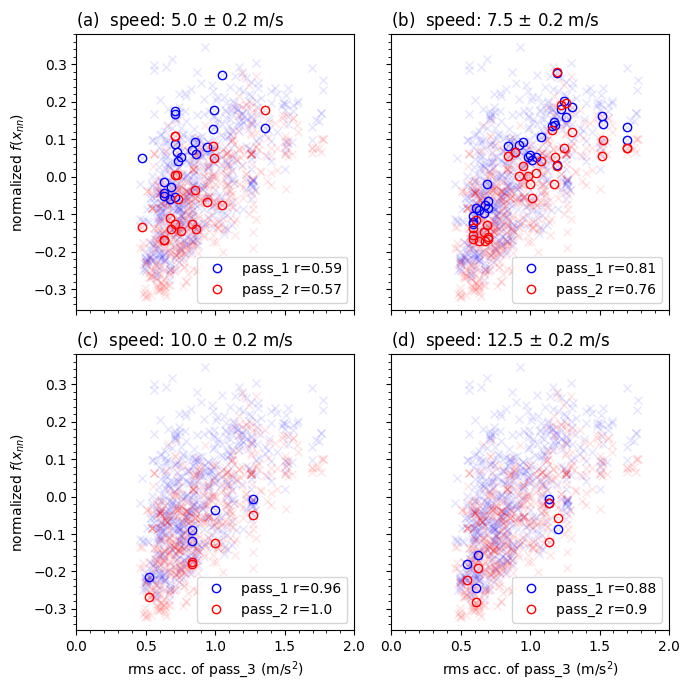

In [70]:
fig, ax = plt.subplots(2, 2, figsize=(7, 7), sharex='all', sharey='all')
ax = ax.flatten()


for i, speed in enumerate(speeds_of_interest):
    subset = {}
    subset['pass3'] = selected_samples[speed][~np.isnan(selected_samples[speed][:, 0]), 1]
    subset['pass1'] = x1_1_pred[~np.isnan(selected_samples[speed][:, 0]), 0]
    subset['pass2'] = x1_2_pred[~np.isnan(selected_samples[speed][:, 0]), 0]
    ax[i].plot(X_3_actual[:, 1], x1_1_pred, color='blue', marker='x', alpha=0.1, linestyle='none')
    ax[i].plot(X_3_actual[:, 1], x1_2_pred, color='red', marker='x', alpha=0.1, linestyle='none')
    ax[i].plot(subset['pass3'], subset['pass1'], color='blue',
               label=f"pass_1 r={np.round(np.corrcoef(subset['pass3'], subset['pass1'])[1,0], 2)}", marker='o', markerfacecolor='none', linestyle='none')
    ax[i].plot(subset['pass3'], subset['pass2'], color='red',
               label=f"pass_2 r={np.round(np.corrcoef(subset['pass3'], subset['pass2'])[1,0], 2)}", marker='o', markerfacecolor='none', linestyle='none')
    ax[i].minorticks_on()
    ax[i].set_title(f"({chr(ord('a')+i)})  speed: {speed} $\pm$ {speeds_of_interest_tol} m/s", loc='left')
    if i > 1:
        ax[i].set_xlabel("rms acc. of pass_3 (m/s$^2$)")
    if (i % 2) == 0:
        ax[i].set_ylabel("normalized $f(x_{nn})$")
    ax[i].legend()
ax[0].set_xlim((0, 2))
plt.tight_layout()
plt.show()
fig.savefig('test_pass_3_simpler_model.pdf')


# plt.figure()
# plt.gca().set_prop_cycle(default_cycler)
# plt.plot(X_3_actual[:, 0], alpha=0.3)
# plt.gca().set_prop_cycle(default_cycler)
# plt.plot(selected_samples[speed][:, 0])

# plt.figure()
# plt.gca().set_prop_cycle(default_cycler)
# plt.plot(X_3_actual[:, 1], alpha=0.3)
# plt.gca().set_prop_cycle(default_cycler)
# plt.plot(selected_samples[speed][:, 1])

# plt.figure()
# plt.gca().set_prop_cycle(default_cycler)
# plt.plot(x1_1_pred, alpha=0.3)
# plt.plot(x1_2_pred, alpha=0.3)
# plt.gca().set_prop_cycle(default_cycler)
# plt.plot((selected_samples[speed][:, 0]/selected_samples[speed][:, 0])*x1_1_pred[:, 0])
# plt.plot((selected_samples[speed][:, 0]/selected_samples[speed][:, 0])*x1_2_pred[:, 0])




# Semaphore based on iso-experience diagram

In [71]:
from typing import Union
from scipy.optimize import minimize_scalar


flag_compute_iso = False


sem_green_yellow_bound = 0.63  # m/s2
sem_yellow_red_bound = 1.6  # m/s2

sem_bounds_norm = scaler_X.transform([[0, sem_green_yellow_bound],
                                      [0, sem_yellow_red_bound]])
sem_green_yellow_bound_norm, sem_yellow_red_bound_norm = sem_bounds_norm[0,1], sem_bounds_norm[1,1]


def pred_f(v: Union[float, np.array], a: Union[float, np.array]):
    v = np.array(v)[0] if np.ndim(v) > 0 else v
    a = np.array(a)[0] if np.ndim(a) > 0 else a
    return model_x1.predict(np.array([[v, a]]), verbose=False)[0,0]


def iso_experience_v(a: float, f: float):
    def pred_f_from_v(v_: float):
        return pred_f(v_, a)
    
    return minimize_scalar(lambda v_: (pred_f_from_v(v_)-f)**2, bounds=(-1, 1), method='bounded', 
                           options={'xatol': 0.01, 'disp': False}).x

if flag_compute_iso:
    sem_green_yellow_speeds_1 = []
    sem_yellow_red_speeds_1 = []
    for sample, f in zip(X_equal[:, :2], x1_1_pred):
        v = iso_experience_v(sem_green_yellow_bound_norm, f)
        sem_green_yellow_speeds_1.append(v)
        v = iso_experience_v(sem_yellow_red_bound_norm, f)
        sem_yellow_red_speeds_1.append(v)
    
    sem_green_yellow_speeds_2 = []
    sem_yellow_red_speeds_2 = []
    for sample, f in zip(X_equal[:, 2:], x1_2_pred):
        v = iso_experience_v(sem_green_yellow_bound_norm, f)
        sem_green_yellow_speeds_2.append(v)
        v = iso_experience_v(sem_yellow_red_bound_norm, f)
        sem_yellow_red_speeds_2.append(v)

In [72]:
import pickle


if flag_compute_iso:
    for i in range(len(sem_green_yellow_speeds_1)):
        sem_green_yellow_speeds_1[i] = float(sem_green_yellow_speeds_1[i])

    for i in range(len(sem_green_yellow_speeds_2)):
        sem_green_yellow_speeds_2[i] = float(sem_green_yellow_speeds_2[i])

    for i in range(len(sem_yellow_red_speeds_1)):
        sem_yellow_red_speeds_1[i] = float(sem_yellow_red_speeds_1[i])

    for i in range(len(sem_yellow_red_speeds_2)):
        sem_yellow_red_speeds_2[i] = float(sem_yellow_red_speeds_2[i])

    with open('sem_green_yellow_speeds_1.pkl', 'wb') as file:
        pickle.dump(sem_green_yellow_speeds_1, file)
    with open('sem_yellow_red_speeds_1.pkl', 'wb') as file:
        pickle.dump(sem_yellow_red_speeds_1, file)
        
    with open('sem_green_yellow_speeds_2.pkl', 'wb') as file:
        pickle.dump(sem_green_yellow_speeds_2, file)
    with open('sem_yellow_red_speeds_2.pkl', 'wb') as file:
        pickle.dump(sem_yellow_red_speeds_2, file)

else:
    with open('sem_green_yellow_speeds_1.pkl', 'rb') as file:
        sem_green_yellow_speeds_1 = pickle.load(file)
    with open('sem_yellow_red_speeds_1.pkl', 'rb') as file:
        sem_yellow_red_speeds_1 = pickle.load(file)
        
    with open('sem_green_yellow_speeds_2.pkl', 'rb') as file:
        sem_green_yellow_speeds_2 = pickle.load(file)
    with open('sem_yellow_red_speeds_2.pkl', 'rb') as file:
        sem_yellow_red_speeds_2 = pickle.load(file)

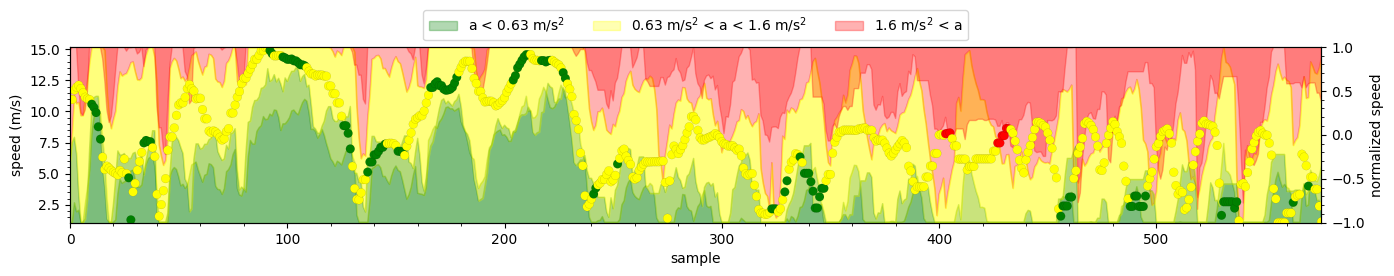

In [73]:
indices = np.arange(len(sem_green_yellow_speeds_1))
fig, ax = plt.subplots(1, 1, figsize=(14,3), sharex='col')

ax_twin = ax.twinx()
ax_twin.minorticks_on()
ax.minorticks_on()

ax_twin.fill_between(indices, -10, sem_green_yellow_speeds_1, color='green', alpha=0.3, 
                label=f'a < {sem_green_yellow_bound} m/s$^2$')
ax_twin.fill_between(indices, sem_green_yellow_speeds_1, sem_yellow_red_speeds_1, color='yellow', alpha=0.3, 
                label=f'{sem_green_yellow_bound} m/s$^2$ < a < {sem_yellow_red_bound} m/s$^2$')
ax_twin.fill_between(indices, sem_yellow_red_speeds_1, max(sem_yellow_red_speeds_1) + 10, color='red', alpha=0.3, 
                label=f'{sem_yellow_red_bound} m/s$^2$ < a')

ax_twin.fill_between(indices, -10, sem_green_yellow_speeds_2, color='green', alpha=0.3, label=None)
ax_twin.fill_between(indices, sem_green_yellow_speeds_2, sem_yellow_red_speeds_1, color='yellow', alpha=0.3, label=None)
ax_twin.fill_between(indices, sem_yellow_red_speeds_2, max(sem_yellow_red_speeds_1) + 10, color='red', alpha=0.3, label=None)

ax.set_xlabel('sample')
ax.set_ylabel('speed (m/s)')
ax.set_ylim([scaler_X.inverse_transform([[-1, 0]])[0,0], scaler_X.inverse_transform([[1, 0]])[0,0]])
ax_twin.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3)
ax.set_xlim([0, indices[-1]])
ax_twin.set_ylabel('normalized speed')
ax_twin.set_ylim([-1, 1])
ax_twin.set_xlim([0, indices[-1]])

# Define colors for actual rms acc. corresponding to pass_3
a = scaler_X.transform(np.array([[np.nan, sem_green_yellow_bound]]))[0,1]
b = scaler_X.transform(np.array([[np.nan, sem_yellow_red_bound]]))[0,1]

# Color assignment function
def get_color(value):
    if value < a:
        return 'green'
    elif a <= value <= b:
        return 'yellow'
    else:
        return 'red'

# Apply the function to obtain the array of colors
colors = np.array([get_color(val) for val in norm(X_3[:, 1])])

# Plot!
ax_twin.scatter(range(X_3.shape[0]), X_3[:, 0], c=colors, edgecolors='k', linewidths=.05, s=40)
# ax_twin.plot(scaler_X.transform(X_equal_actual[:, :2])[:, 0], color='blue', linestyle='-', label='pass_3', linewidth=0.5)
# ax_twin.plot(scaler_X.transform(X_equal_actual[:, 2:])[:, 0], color='red', linestyle='-', label='pass_3', linewidth=0.5)

plt.tight_layout()
plt.savefig('semaphore'+'_simpler_model.pdf')
plt.show()

## Confusion matrix

In [74]:
# Predictions for pass_3
# Color assignment function
def pred_color(i, speed, pass_i):
    if pass_i == 1:
        a = sem_green_yellow_speeds_1[i]
        b = sem_yellow_red_speeds_1[i]
    elif pass_i == 2:
        a = sem_green_yellow_speeds_2[i]
        b = sem_yellow_red_speeds_2[i]
    elif pass_i == 'ensemble':
        if speed < sem_green_yellow_speeds_1[i] and speed < sem_green_yellow_speeds_2[i]:
            return 'green'
        elif sem_green_yellow_speeds_1[i] <= speed <= sem_yellow_red_speeds_1[i] and sem_green_yellow_speeds_2[i] <= speed <= sem_yellow_red_speeds_2[i]:
            return 'yellow'
        elif speed > sem_yellow_red_speeds_1[i] and speed > sem_yellow_red_speeds_2[i]:
            return 'red'
        else:
            return '-'
    else:
        raise NotImplementedError
        
    if speed < a:
        return 'green'
    elif a <= speed <= b:
        return 'yellow'
    else:
        return 'red'
    

# Apply the function to obtain the array of colors
colors_pred_pass1 = np.array([pred_color(i, speed, 1) for (i, speed) in enumerate(norm(X_3[:, 0]))])
colors_pred_pass2 = np.array([pred_color(i, speed, 2) for (i, speed) in enumerate(norm(X_3[:, 0]))])
colors_pred_ensemble = np.array([pred_color(i, speed, 'ensemble') for (i, speed) in enumerate(norm(X_3[:, 0]))])

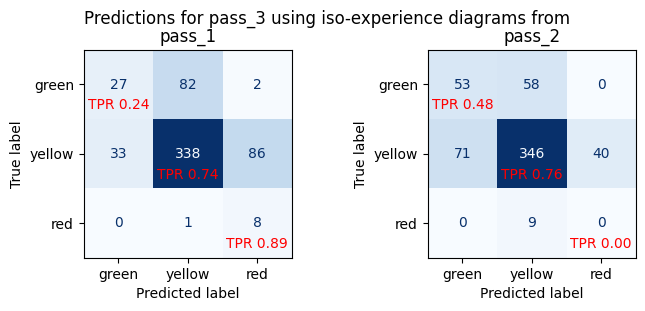

In [75]:
from sklearn import metrics


# class_names = ['green', 'yellow', 'red', '-']
class_names = ['green', 'yellow', 'red']


# Compute confusion matrices
cm_pass1 = metrics.confusion_matrix(colors, y_pred=colors_pred_pass1, labels=class_names)
cm_pass2 = metrics.confusion_matrix(colors, y_pred=colors_pred_pass2, labels=class_names)
# cm_ensemble = metrics.confusion_matrix(colors, y_pred=colors_pred_ensemble, labels=class_names)

# Compute per-class accuracies
report1 = metrics.classification_report(colors, colors_pred_pass1, labels=class_names, output_dict=True, zero_division=np.nan)
report2 = metrics.classification_report(colors, colors_pred_pass2, labels=class_names, output_dict=True, zero_division=np.nan)


cm_pass1_plot = metrics.ConfusionMatrixDisplay(cm_pass1, display_labels=class_names)
cm_pass2_plot = metrics.ConfusionMatrixDisplay(cm_pass2, display_labels=class_names)
# cm_ensemble_plot = metrics.ConfusionMatrixDisplay(cm_ensemble, display_labels=class_names)

# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 3.5), sharey='row')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

fig.suptitle('Predictions for pass_3 using iso-experience diagrams from')
ax1.set_title('pass_1')
ax2.set_title('pass_2')
cm_pass1_plot.plot(ax=ax1, cmap='Blues', colorbar=False)
cm_pass2_plot.plot(ax=ax2, cmap='Blues', colorbar=False)
# cm_ensemble_plot.plot(ax=ax3, cmap='Blues', colorbar=False)

# Add per-class accuracy and TPR to the subplot
for i, label in enumerate(class_names):
    tpr1, tpr2 = report1[str(label)]["recall"], report2[str(label)]["recall"]
    ax1.text(i, i+0.3, f'TPR {tpr1:.2f}', ha='center', va='center', color='red')
    ax2.text(i, i+0.3, f'TPR {tpr2:.2f}', ha='center', va='center', color='red')

# Show the plot
plt.tight_layout(pad=0.2, w_pad=0.1, h_pad=2.0)
plt.savefig('semaphore_cm'+'_simpler_model.pdf')
plt.show()

# FFT of raw acc

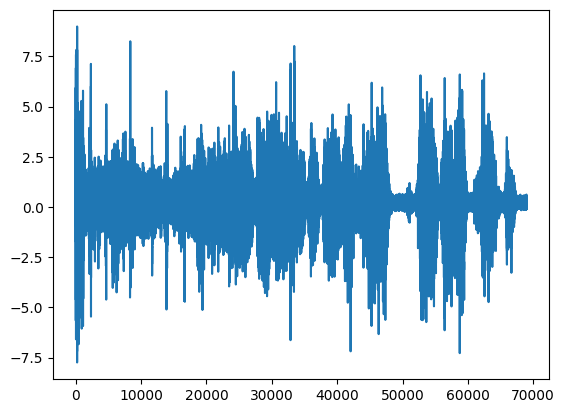

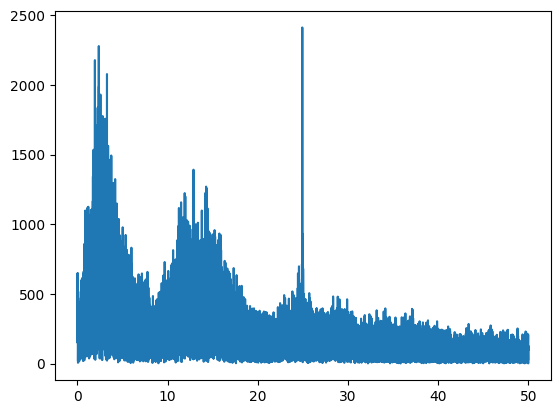

In [76]:
from scipy import fft


freqs = fft.fftfreq(acc_orig_df_1['z'].values.shape[0], 1/100)[1:acc_orig_df_1['z'].values.shape[0]//2]
plt.plot(acc_orig_df_1['z'])
plt.figure()
plt.plot(freqs,
         abs(fft.fft(acc_orig_df_1['z'].values - np.mean(acc_orig_df_1['z'].values))[1:acc_orig_df_1['z'].values.shape[0]//2]))
# plt.ylim([0,500])
